# Prep

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import pandas as pd

REPO_PATH = '/content/pointcloud-bench'
DRIVE_PATH = '/content/drive/MyDrive/pointcloud-bench'
RESULTS_DIR = os.path.join(DRIVE_PATH, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

In [3]:
# Get repo. For now on mc_accuracy branch, once merged just use main
!git clone --recursive --branch mc_accuracy https://github.com/DavidClaszen/pointcloud-bench {REPO_PATH}
%cd {REPO_PATH}
# Exclude lie learn, not necessary here, has to build wheel
!grep -v "lie_learn @ git+https://github.com/AMLab-Amsterdam/lie_learn@master" envs/analysis/requirements.txt | pip install -r /dev/stdin

Cloning into '/content/pointcloud-bench'...
remote: Enumerating objects: 690, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 690 (delta 48), reused 53 (delta 42), pack-reused 605 (from 1)
Receiving objects: 100% (690/690), 64.52 MiB | 27.50 MiB/s, done.
Resolving deltas: 100% (317/317), done.
Submodule 'repos/PAPNet' (https://github.com/DavidClaszen/PAPNet.git) registered for path 'repos/PAPNet'
Submodule 'repos/Point-Transformers' (https://github.com/DavidClaszen/Point-Transformers.git) registered for path 'repos/Point-Transformers'
Cloning into '/content/pointcloud-bench/repos/PAPNet'...
remote: Enumerating objects: 145, done.        
remote: Counting objects: 100% (145/145), done.        
remote: Compressing objects: 100% (117/117), done.        
remote: Total 145 (delta 63), reused 88 (delta 27), pack-reused 0 (from 0)        
Receiving objects: 100% (145/145), 9.66 MiB | 12.17 MiB/s, done.
Resolving deltas: 100% (

# Plot PAPNet logs

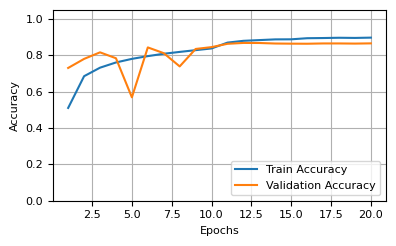

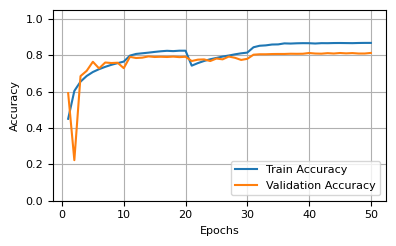

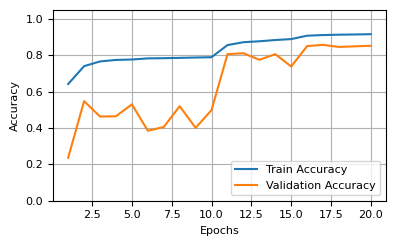

In [ ]:
from notebooks.visuals import plot_log

LOG_PATH = os.path.join(RESULTS_DIR, 'logs_papnet')
PLOT_PATH = os.path.join(RESULTS_DIR, 'curves_papnet')
os.makedirs(PLOT_PATH, exist_ok=True)
logs = os.listdir(LOG_PATH)

for log in logs:
    df = pd.read_csv(os.path.join(LOG_PATH, log))
    df = df.rename(columns={'epoch': 'epochs', 'train_ins_acc': 'train', 'test_ins_acc': 'test'})
    df['model'] = log.replace('.csv', '')
    plot_log(
        df=df,
        store_plots=PLOT_PATH,
        figsize=(4, 2.5),
        title='',
        font_size=8
    )